# 04 · Mid-term Signal Processing Analysis

This notebook is intentionally reduced for the mid-term review.

**Keep and defend:** filtering, frequency-domain analysis, heart-rate/cepstral analysis, and a simple time-frequency representation.

**Postpone:** coherence, ICA, Otsu/GLCM texture analysis, image compression, and other extended analyses unless the Signal & Image Processing teacher explicitly requires them.


In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")
%run ../common/01_signal_lib.ipynb

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

df = pd.read_csv(P["metadata"] / "records_qc.csv")
df = df[df.qc_keep].reset_index(drop=True)
sig = np.load(P["segments"] / "signals.npz")
fs = CFG["preprocessing"]["fs"]
lab = df[df.murmur_label.isin(["Present", "Absent"])].copy()

print("Usable recordings:", len(df))
print("Labelled recordings:", len(lab))
print("Sampling rate:", fs, "Hz")


Python environment is working
PyTorch: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


loaded 01_signal_lib


Usable recordings: 3163
Labelled recordings: 3007
Sampling rate: 2000 Hz


## 1. IIR vs FIR band-pass filtering

The project uses a 20–800 Hz band-pass. Compare the existing Butterworth IIR implementation with an FIR implementation to demonstrate the filtering concept.

For the mid-term, the important explanation is:

- IIR: fewer coefficients and computationally efficient.
- FIR: linear-phase design is possible, but usually requires more taps.
- The project uses the Butterworth IIR pipeline for preprocessing.


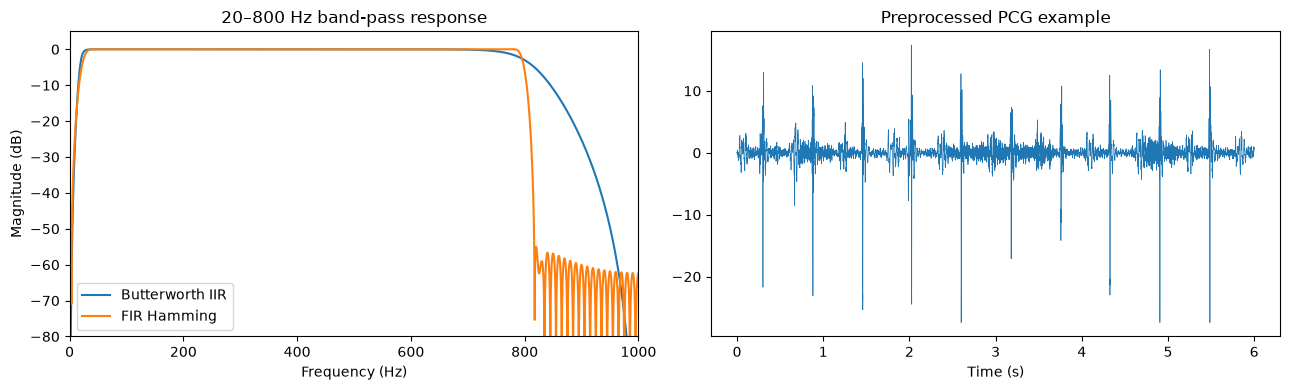

In [2]:
sos = butter_bandpass_sos(20, 800, fs, 4)
taps = fir_bandpass(20, 800, fs, 201)

w, h_iir = sps.sosfreqz(sos, 4096, fs=fs)
_, h_fir = sps.freqz(taps, 1, 4096, fs=fs)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(w, 20*np.log10(np.abs(h_iir) + 1e-12), label="Butterworth IIR")
ax[0].plot(w, 20*np.log10(np.abs(h_fir) + 1e-12), label="FIR Hamming")
ax[0].set_xlim(0, 1000)
ax[0].set_ylim(-80, 5)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Magnitude (dB)")
ax[0].set_title("20–800 Hz band-pass response")
ax[0].legend()

x = sig[lab.record_id.iloc[0]].astype(np.float32)
t = np.arange(len(x))/fs
ax[1].plot(t[:6*fs], x[:6*fs], lw=0.5)
ax[1].set_xlabel("Time (s)")
ax[1].set_title("Preprocessed PCG example")
plt.tight_layout()
savefig(fig, "04_midterm_filtering")
plt.show()


## 2. Welch power spectral density

PSD shows how signal energy is distributed across frequency.

The RL action space later uses candidate frequency/representation choices, so PSD is a useful signal descriptor.


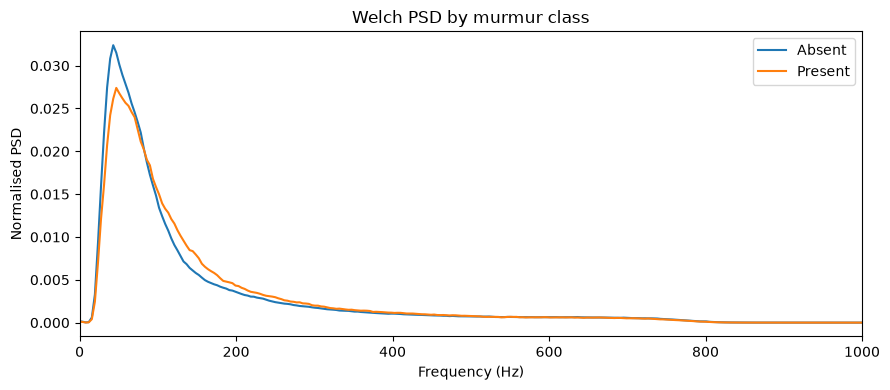

,band,AUROC
0,20-100 Hz,0.427509
1,100-200 Hz,0.622564
2,200-400 Hz,0.556754
3,400-800 Hz,0.493922
4,20-800 Hz,0.619879


In [3]:
def psd_of(rid):
    f, p = welch_psd(sig[rid].astype(np.float32), fs, 512)
    p = p / (p.sum() + 1e-12)
    return f, p

f, _ = psd_of(lab.record_id.iloc[0])
psd = {
    c: np.stack([psd_of(r)[1] for r in lab.record_id[lab.murmur_label == c]])
    for c in ["Absent", "Present"]
}

fig, ax = plt.subplots(figsize=(9, 4))
for c, arr in psd.items():
    m = np.median(arr, axis=0)
    ax.plot(f, m, label=c)
ax.set_xlim(0, 1000)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Normalised PSD")
ax.set_title("Welch PSD by murmur class")
ax.legend()
plt.tight_layout()
savefig(fig, "04_midterm_psd")
plt.show()

rows = []
for lo, hi in CFG["actions"]["band"]:
    mask = (f >= lo) & (f < hi)
    e0 = np.log(psd["Absent"][:, mask].sum(axis=1) + 1e-12)
    e1 = np.log(psd["Present"][:, mask].sum(axis=1) + 1e-12)
    yy = np.r_[np.zeros(len(e0)), np.ones(len(e1))]
    auc = roc_auc_score(yy, np.r_[e0, e1])
    rows.append({"band": f"{lo}-{hi} Hz", "AUROC": auc})

band_tab = pd.DataFrame(rows)
band_tab.to_csv(P["tables"] / "04_midterm_psd_band_summary.csv", index=False)
band_tab


## 3. Homomorphic envelope and cepstral heart rate

The envelope makes the cardiac cycle easier to analyse. The cepstrum can estimate the periodicity of the heart sound.

This is retained because it is a concrete signal-processing feature that can also contribute to the RL state.


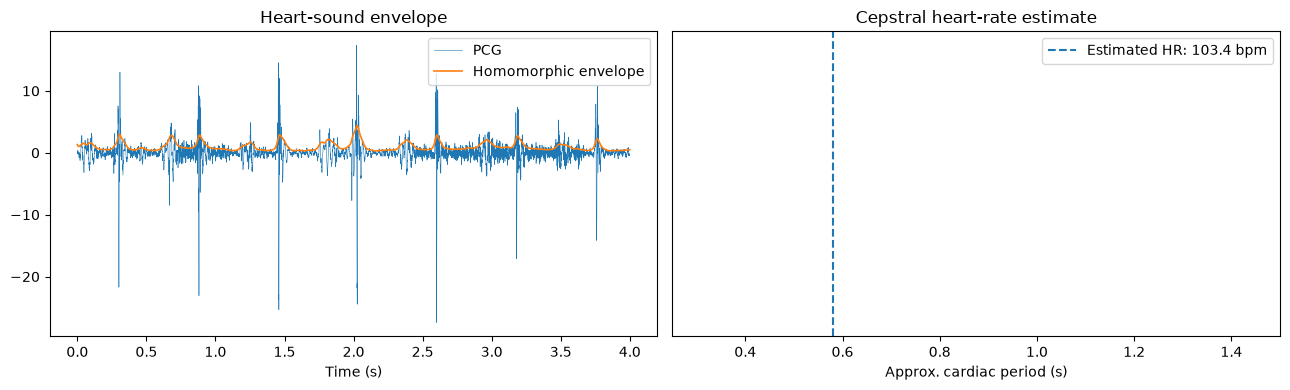

Estimated heart rate: 103.45 bpm


In [4]:
ex = lab.iloc[0]
x = sig[ex.record_id].astype(np.float32)

env = homomorphic_envelope(x, fs)
bpm, prom = cepstral_heart_rate(x, fs)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
t = np.arange(len(x))/fs
ax[0].plot(t[:4*fs], x[:4*fs], lw=0.4, label="PCG")
ax[0].plot(t[:4*fs], env[:4*fs], lw=1.2, label="Homomorphic envelope")
ax[0].set_xlabel("Time (s)")
ax[0].set_title("Heart-sound envelope")
ax[0].legend()

q = np.arange(1, 3, 0.01)
ax[1].axvline(60/bpm, ls="--", label=f"Estimated HR: {bpm:.1f} bpm")
ax[1].set_xlim(0.25, 1.5)
ax[1].set_xlabel("Approx. cardiac period (s)")
ax[1].set_yticks([])
ax[1].set_title("Cepstral heart-rate estimate")
ax[1].legend()

plt.tight_layout()
savefig(fig, "04_midterm_cepstrum")
plt.show()
print("Estimated heart rate:", round(float(bpm), 2), "bpm")


## 4. Time-frequency representation

A heart sound is non-stationary, so both time and frequency matter.

For the mid-term, demonstrate one STFT and one wavelet-packet representation. The later project can use these representations inside the larger CNN/attention-fusion architecture.


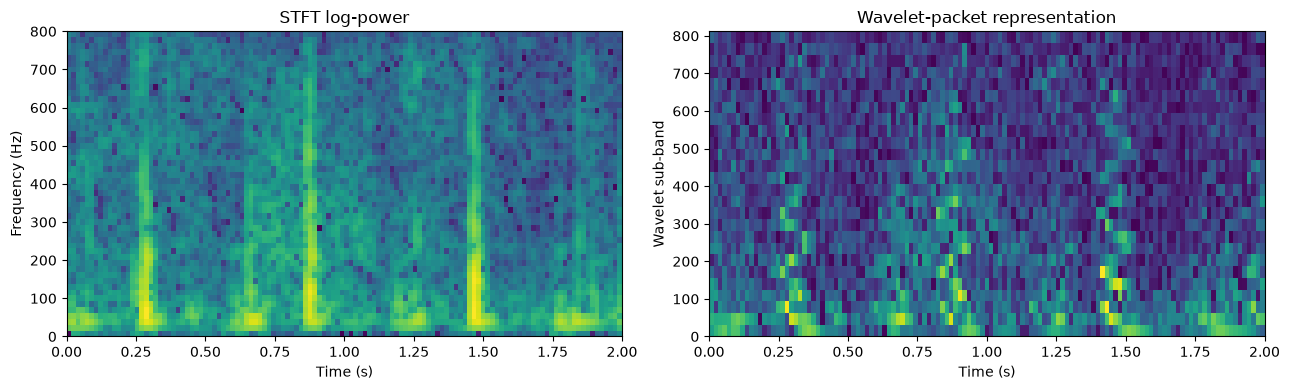

In [5]:
rid = lab.record_id.iloc[0]
x = sig[rid].astype(np.float32)[:2*fs]

fq, Pw = stft_power(x, fs, 128, 32)
img = np.log(Pw[fq <= 800] + 1e-6)

M = wavelet_packet_matrix(
    x[:(len(x)//32)*32],
    "db6",
    5
)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].imshow(img, origin="lower", aspect="auto",
             extent=[0, 2, 0, 800])
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Frequency (Hz)")
ax[0].set_title("STFT log-power")

ax[1].imshow(log_compress(M[:26]), origin="lower",
             aspect="auto", extent=[0, 2, 0, 812])
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Wavelet sub-band")
ax[1].set_title("Wavelet-packet representation")

plt.tight_layout()
savefig(fig, "04_midterm_time_frequency")
plt.show()


### Mid-term takeaway

The signal-processing pipeline now has four easy-to-defend pieces:

**Preprocessing → filtering → spectral/cepstral descriptors → time-frequency representation**

The RL notebooks use a compact subset of these descriptors as the state and a small wavelet-selection action space.

The extended ICA, coherence, texture, segmentation and compression experiments remain outside the mid-term run.
